<a href="https://colab.research.google.com/github/Macky091/CST9L-FinalExam/blob/main/phishing_website_detection_random_forestFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phishing Website Detection — Random Forest (Baseline vs. Tuned)

This notebook loads `dataset1.csv`, checks and preprocesses the data, trains an initial Random Forest model, tunes a second model with cross-validation, compares both models with metrics and graphs, and saves the processed dataset and trained model files.

**Dataset assumptions:** `Result` is the target column (`-1` and `1` labels), and `index` is an identifier rather than a predictive feature. The notebook verifies these assumptions from the data. It does not fabricate or rename the target labels.

## 1. Imports and reproducibility

If a library is missing, install it in your notebook environment with `pip install pandas numpy scikit-learn matplotlib seaborn joblib`.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

RANDOM_STATE = 42
TEST_SIZE = 0.20
DATA_PATH = Path("dataset1.csv")  # Put dataset1.csv in the same folder as this notebook
OUTPUT_DIR = Path("phishing_model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## 2. Load and inspect the dataset

The loader first checks the notebook's current directory. If the CSV is elsewhere, update `DATA_PATH` above to its path.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. Place dataset1.csv beside this notebook "
        "or change DATA_PATH to the correct file path."
    )

df = pd.read_csv(DATA_PATH)
# Remove accidental whitespace from column names
df.columns = df.columns.astype(str).str.strip()

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())
print("\\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False).head(15))
print("\\nDuplicate rows:", df.duplicated().sum())
print("\\nTarget distribution:")
if "Result" not in df.columns:
    raise ValueError("Expected target column 'Result' was not found. Check df.columns.")
display(df["Result"].value_counts(dropna=False).sort_index())

Dataset shape: (11055, 32)


,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   index                        11055 non-null  int64
 1   having_IPhaving_IP_Address   11055 non-null  int64
 2   URLURL_Length                11055 non-null  int64
 3   Shortining_Service           11055 non-null  int64
 4   having_At_Symbol             11055 non-null  int64
 5   double_slash_redirecting     11055 non-null  int64
 6   Prefix_Suffix                11055 non-null  int64
 7   having_Sub_Domain            11055 non-null  int64
 8   SSLfinal_State               11055 non-null  int64
 9   Domain_registeration_length  11055 non-null  int64
 10  Favicon                      11055 non-null  int64
 11  port                         11055 non-null  int64
 12  HTTPS_token                  11055 non-null  int64
 13  Request_URL                  11055 non-null  i

None

\nMissing values per column:


,0
index,0
having_IPhaving_IP_Address,0
URLURL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0


\nDuplicate rows: 0
\nTarget distribution:


,count
Result,
-1,4898
1,6157


## 3. Preprocess

- Remove duplicate rows.
- Drop the `index` identifier column if present, because row IDs should not be used as model features.
- Convert feature and target columns to numeric values and impute any missing feature values using the training-set median.
- Keep the original target labels. The supplied dataset commonly uses `-1` and `1`; the code handles the labels as provided.
- Split the data with stratification before fitting imputation, avoiding test-data leakage.
- Save a cleaned, preprocessed copy of the full dataset for reuse. The median imputer used for modeling is fitted on training data only.

In [3]:
df = df.copy()
df.columns = df.columns.astype(str).str.strip()
df = df.drop_duplicates().reset_index(drop=True)

target_col = "Result"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found. Available columns: {df.columns.tolist()}")

# Remove common identifier columns; they are not meaningful predictive inputs.
id_cols = [c for c in df.columns if c.lower() in {"index", "id", "unnamed: 0"}]
df_model = df.drop(columns=id_cols, errors="ignore")

# Numeric conversion for this dataset's encoded features.
for col in df_model.columns:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Rows without a known target cannot be used for supervised training.
df_model = df_model.dropna(subset=[target_col]).reset_index(drop=True)
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

if y.nunique() < 2:
    raise ValueError("The target column has fewer than two classes; classification cannot be trained.")
if X.shape[1] == 0:
    raise ValueError("No feature columns remain after preprocessing.")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Median imputation fitted ONLY on training data, then applied to train and test.
medians = X_train_raw.median(numeric_only=True)
X_train = X_train_raw.fillna(medians).fillna(0)
X_test = X_test_raw.fillna(medians).fillna(0)

# Save the clean full dataset (identifier removed, missing numeric features imputed using
# full-data medians for a reusable cleaned export; model evaluation still uses train-only imputation).
X_export = X.fillna(X.median(numeric_only=True)).fillna(0)
processed_export = X_export.copy()
processed_export[target_col] = y.reset_index(drop=True)
processed_path = OUTPUT_DIR / "phishing_preprocessed_dataset.csv"
processed_export.to_csv(processed_path, index=False)

print("Rows after cleaning:", len(df_model))
print("Feature count:", X.shape[1])
print("Classes:", sorted(y.unique().tolist()))
print("Training rows:", len(X_train), "| Test rows:", len(X_test))
print("Saved preprocessed dataset to:", processed_path.resolve())
display(processed_export.head())

Rows after cleaning: 11055
Feature count: 30
Classes: [-1, 1]
Training rows: 8844 | Test rows: 2211
Saved preprocessed dataset to: /content/phishing_model_outputs/phishing_preprocessed_dataset.csv


,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1


## 4. Explore the data

These plots help understand class balance, feature distributions, and correlations. The correlation heatmap can be large, so labels are kept small.

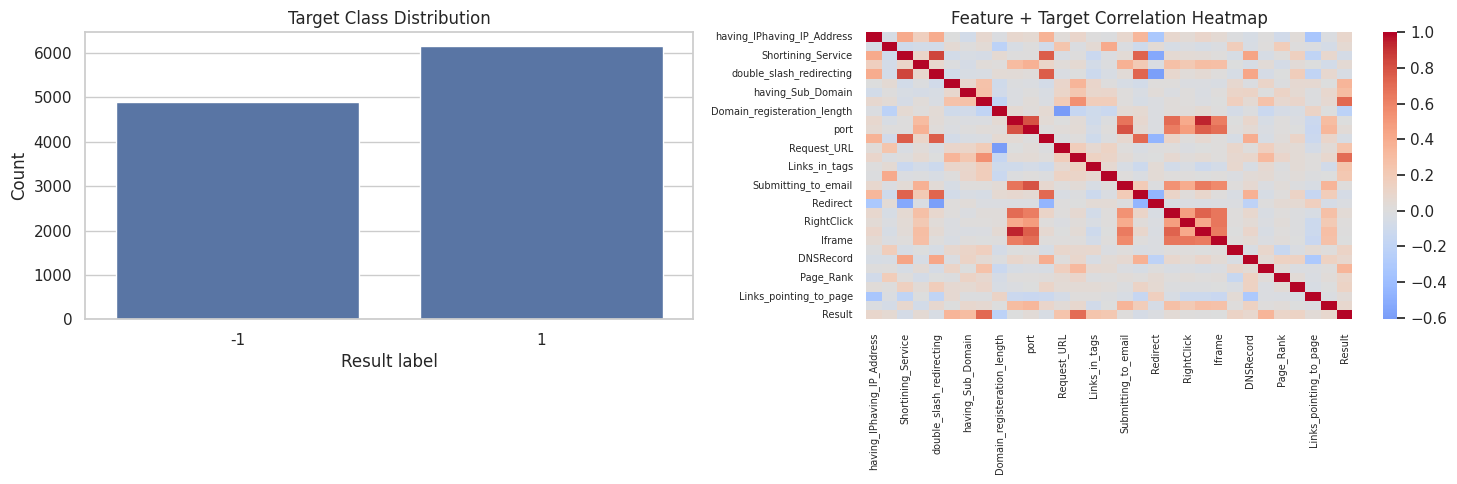

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(x=y.astype(str), ax=axes[0])
axes[0].set_title("Target Class Distribution")
axes[0].set_xlabel("Result label")
axes[0].set_ylabel("Count")

corr = pd.concat([X_export, y.rename(target_col)], axis=1).corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, ax=axes[1], cbar=True)
axes[1].set_title("Feature + Target Correlation Heatmap")
axes[1].tick_params(axis="x", labelrotation=90, labelsize=7)
axes[1].tick_params(axis="y", labelrotation=0, labelsize=7)
plt.tight_layout()
plt.show()

## 5. Train the initial Random Forest model

This is the baseline model using mostly standard Random Forest settings. It is trained on the training split only.

In [5]:
baseline_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)

print("INITIAL / BASELINE MODEL")
print(classification_report(y_test, baseline_pred, zero_division=0))

INITIAL / BASELINE MODEL
              precision    recall  f1-score   support

          -1       0.98      0.97      0.97       980
           1       0.97      0.98      0.98      1231

    accuracy                           0.98      2211
   macro avg       0.98      0.97      0.97      2211
weighted avg       0.98      0.98      0.98      2211



## 6. Tune a second Random Forest model

Grid search uses stratified 5-fold cross-validation on the training split and optimizes F1 macro, which gives each class equal weight. This is more robust than tuning against the test set. The grid is intentionally moderate; increase it if you have more compute time.

In [6]:
param_grid = {
    "n_estimators": [150, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.8]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)
grid_search.fit(X_train, y_train)

tuned_model = grid_search.best_estimator_
tuned_pred = tuned_model.predict(X_test)
tuned_proba = tuned_model.predict_proba(X_test)

print("Best CV macro-F1:", round(grid_search.best_score_, 4))
print("Best parameters:")
print(grid_search.best_params_)
print("\\nTUNED MODEL")
print(classification_report(y_test, tuned_pred, zero_division=0))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best CV macro-F1: 0.9686
Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
\nTUNED MODEL
              precision    recall  f1-score   support

          -1       0.98      0.96      0.97       980
           1       0.97      0.98      0.98      1231

    accuracy                           0.97      2211
   macro avg       0.98      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



## 7. Compare evaluation metrics

For precision, recall, and F1, macro averages treat each class equally. ROC-AUC uses the probability for the positive class chosen by scikit-learn's class ordering. The positive class label is printed below so the ROC plot is interpretable.

,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC
Model,,,,,
Initial Random Forest,0.9751,0.9755,0.9741,0.9748,0.9978
Tuned Random Forest,0.9747,0.9752,0.9735,0.9743,0.9978


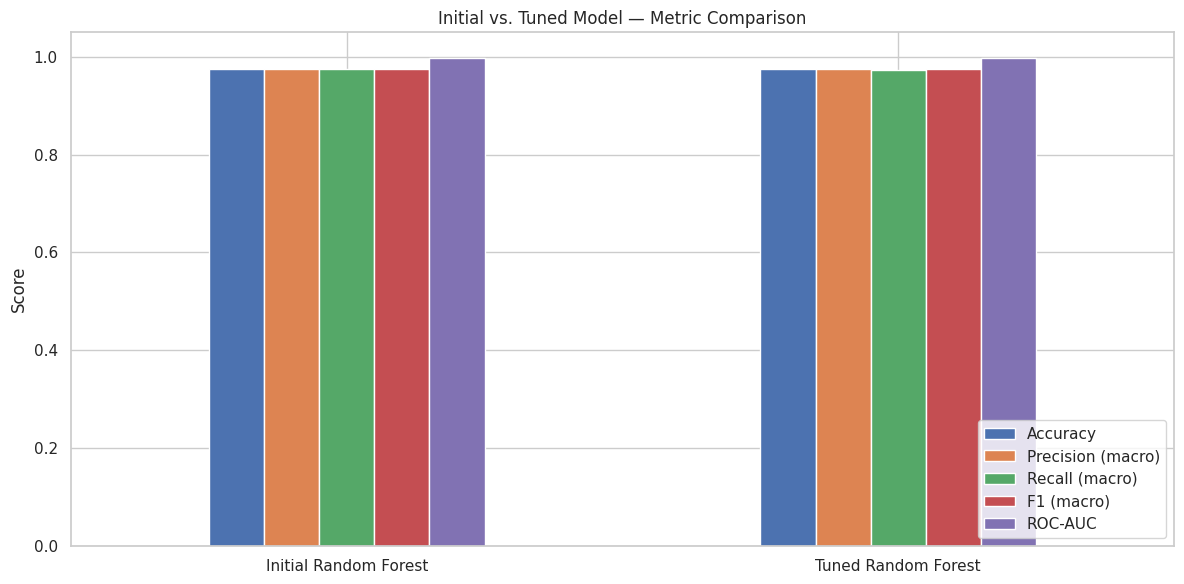

In [7]:
def metric_row(name, model, pred, proba):
    classes = list(model.classes_)
    # For binary classification, use the second class in sklearn's sorted class order for ROC-AUC.
    auc = np.nan
    if len(classes) == 2:
        positive_label = classes[1]
        y_binary = (y_test == positive_label).astype(int)
        positive_probs = proba[:, classes.index(positive_label)]
        auc = roc_auc_score(y_binary, positive_probs)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (macro)": precision_score(y_test, pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_test, pred, average="macro", zero_division=0),
        "ROC-AUC": auc
    }

metrics_df = pd.DataFrame([
    metric_row("Initial Random Forest", baseline_model, baseline_pred, baseline_proba),
    metric_row("Tuned Random Forest", tuned_model, tuned_pred, tuned_proba)
]).set_index("Model")

display(metrics_df.round(4))
metrics_df.to_csv(OUTPUT_DIR / "model_comparison_metrics.csv")

ax = metrics_df.plot(kind="bar", figsize=(12, 6), ylim=(0, 1.05), rot=0)
ax.set_title("Initial vs. Tuned Model — Metric Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "metrics_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Confusion matrices side by side

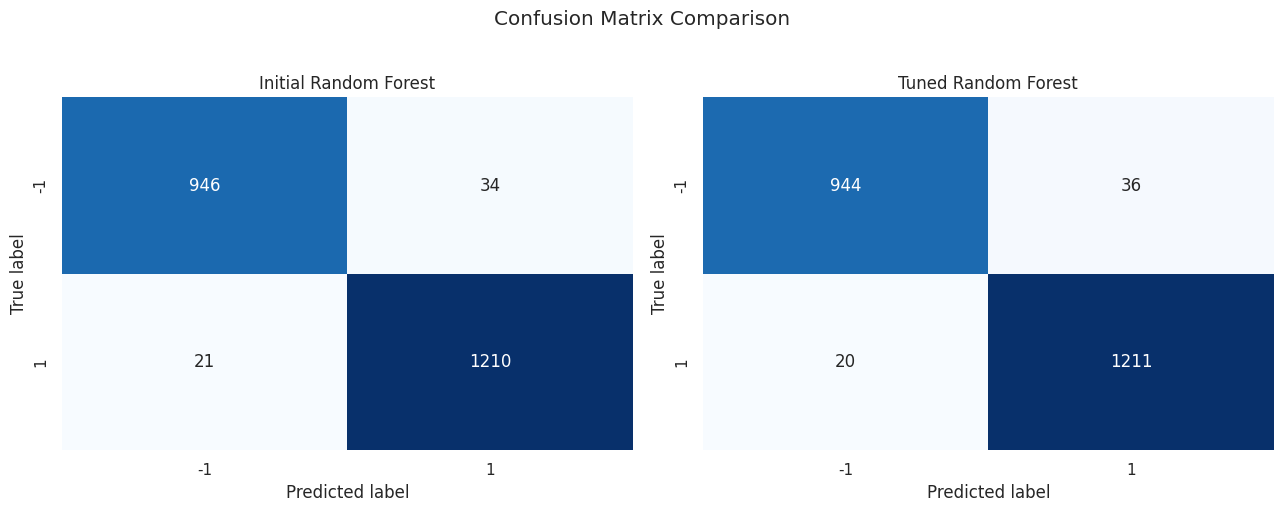

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = list(baseline_model.classes_)
for ax, pred, title in [
    (axes[0], baseline_pred, "Initial Random Forest"),
    (axes[1], tuned_pred, "Tuned Random Forest")
]:
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
plt.suptitle("Confusion Matrix Comparison", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. ROC curves side by side

ROC is plotted only for binary classification. AUC values are computed from the held-out test set.

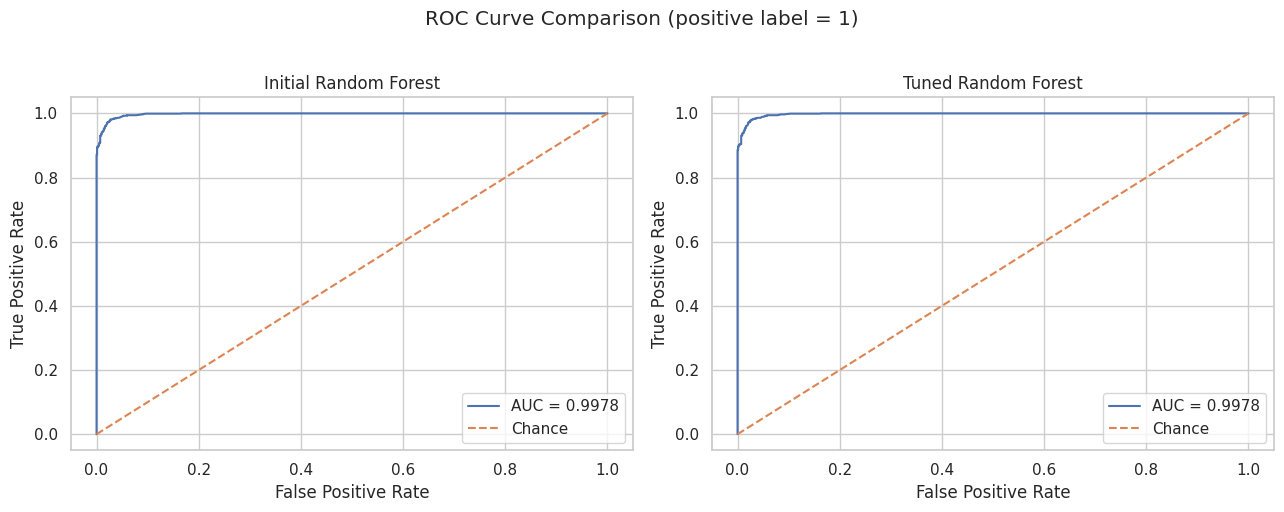

In [9]:
if len(baseline_model.classes_) == 2:
    classes = list(baseline_model.classes_)
    positive_label = classes[1]
    y_binary = (y_test == positive_label).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, model, proba, title in [
        (axes[0], baseline_model, baseline_proba, "Initial Random Forest"),
        (axes[1], tuned_model, tuned_proba, "Tuned Random Forest")
    ]:
        pos_idx = list(model.classes_).index(positive_label)
        fpr, tpr, thresholds = roc_curve(y_binary, proba[:, pos_idx])
        auc = roc_auc_score(y_binary, proba[:, pos_idx])
        ax.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
        ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")
        ax.set_title(title)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(loc="lower right")
    plt.suptitle(f"ROC Curve Comparison (positive label = {positive_label})", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "roc_curves_comparison.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("ROC curve comparison is skipped because this target has more than two classes.")

## 10. Feature importance side by side

Random Forest feature importance is shown for both models. This is a model-based ranking, not proof of causation. The top features are selected from the combined top ranks to make the comparison readable.

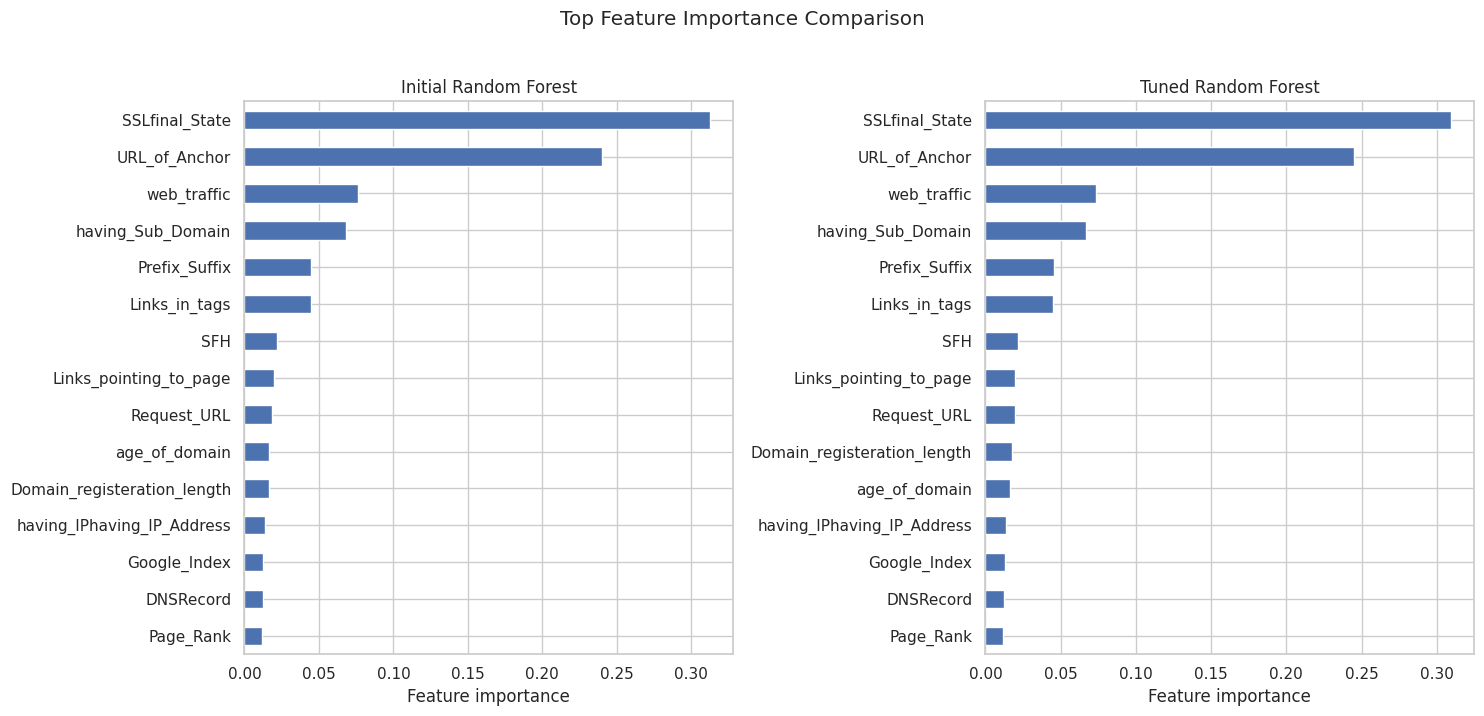

,Initial importance,Tuned importance
SSLfinal_State,0.31237,0.30931
URL_of_Anchor,0.23976,0.24494
web_traffic,0.07626,0.07366
having_Sub_Domain,0.06847,0.06653
Prefix_Suffix,0.04488,0.04548
Links_in_tags,0.04439,0.04510
SFH,0.02164,0.02151
Links_pointing_to_page,0.01994,0.01979
Request_URL,0.01877,0.01954
Domain_registeration_length,0.01637,0.01732


In [10]:
imp_base = pd.Series(baseline_model.feature_importances_, index=X_train.columns, name="Initial")
imp_tuned = pd.Series(tuned_model.feature_importances_, index=X_train.columns, name="Tuned")
top_features = list((imp_base.add(imp_tuned, fill_value=0).sort_values(ascending=False).head(15)).index)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, importance, title in [
    (axes[0], imp_base, "Initial Random Forest"),
    (axes[1], imp_tuned, "Tuned Random Forest")
]:
    plot_data = importance.loc[top_features].sort_values()
    plot_data.plot(kind="barh", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Feature importance")
    ax.set_ylabel("")
plt.suptitle("Top Feature Importance Comparison", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

importance_comparison = pd.DataFrame({
    "Initial importance": imp_base,
    "Tuned importance": imp_tuned
}).sort_values("Tuned importance", ascending=False)
display(importance_comparison.head(20).round(5))
importance_comparison.to_csv(OUTPUT_DIR / "feature_importance_comparison.csv")

## 11. Prediction error and probability comparison

The probability distributions can help reveal whether one model is more confident. Confidence is not the same as correctness, so interpret alongside the confusion matrices and ROC-AUC.

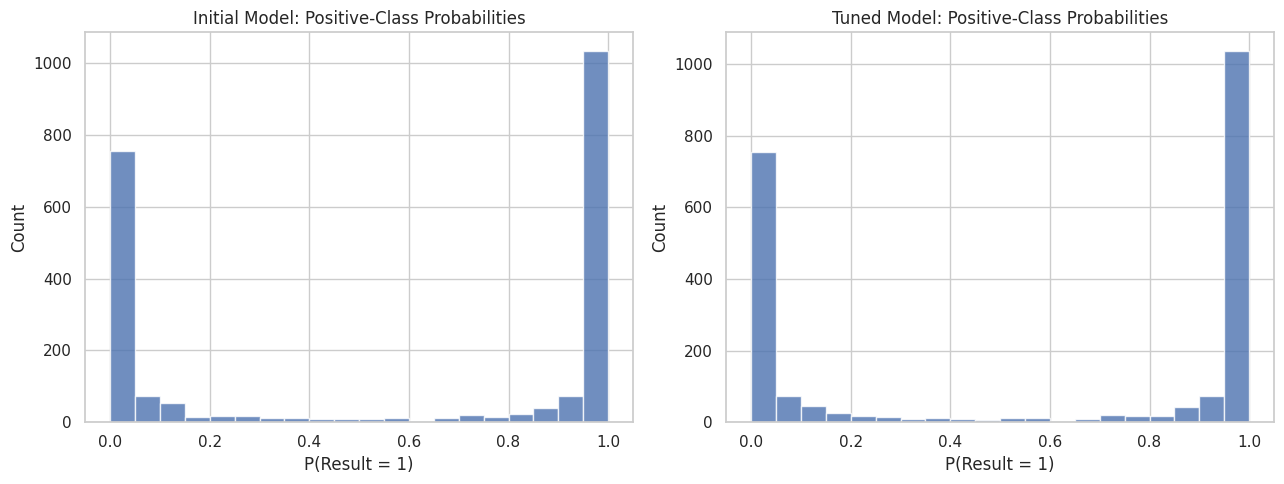

In [11]:
if len(baseline_model.classes_) == 2:
    classes = list(baseline_model.classes_)
    positive_label = classes[1]
    pos_idx_base = list(baseline_model.classes_).index(positive_label)
    pos_idx_tuned = list(tuned_model.classes_).index(positive_label)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].hist(baseline_proba[:, pos_idx_base], bins=20, alpha=0.8)
    axes[0].set_title("Initial Model: Positive-Class Probabilities")
    axes[0].set_xlabel(f"P(Result = {positive_label})")
    axes[0].set_ylabel("Count")

    axes[1].hist(tuned_proba[:, pos_idx_tuned], bins=20, alpha=0.8)
    axes[1].set_title("Tuned Model: Positive-Class Probabilities")
    axes[1].set_xlabel(f"P(Result = {positive_label})")
    axes[1].set_ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "probability_distributions.png", dpi=200, bbox_inches="tight")
    plt.show()

## 12. Save models and preprocessing artifacts

Saved artifacts:
- `phishing_preprocessed_dataset.csv` — cleaned dataset for reuse.
- `initial_random_forest.joblib` — baseline model.
- `tuned_random_forest.joblib` — best tuned model.
- `model_artifacts.joblib` — model, feature names, target name, train-fitted imputation medians, and class labels for future inference.
- PNG graphs and CSV metric/importance tables.

For future predictions, use the same feature columns and apply the saved training medians before calling `model.predict()`.

In [12]:
joblib.dump(baseline_model, OUTPUT_DIR / "initial_random_forest.joblib")
joblib.dump(tuned_model, OUTPUT_DIR / "tuned_random_forest.joblib")

artifacts = {
    "model": tuned_model,
    "feature_names": list(X_train.columns),
    "target_name": target_col,
    "training_medians": medians.to_dict(),
    "classes": list(tuned_model.classes_),
    "best_params": grid_search.best_params_,
    "random_state": RANDOM_STATE
}
joblib.dump(artifacts, OUTPUT_DIR / "model_artifacts.joblib")

print("Saved files:")
for file in sorted(OUTPUT_DIR.iterdir()):
    print(f" - {file.name} ({file.stat().st_size:,} bytes)")

Saved files:
 - confusion_matrices_comparison.png (59,753 bytes)
 - feature_importance_comparison.csv (1,714 bytes)
 - feature_importance_comparison.png (153,920 bytes)
 - initial_random_forest.joblib (22,562,057 bytes)
 - metrics_comparison.png (71,025 bytes)
 - model_artifacts.joblib (33,873,226 bytes)
 - model_comparison_metrics.csv (298 bytes)
 - phishing_preprocessed_dataset.csv (789,159 bytes)
 - probability_distributions.png (64,062 bytes)
 - roc_curves_comparison.png (106,430 bytes)
 - tuned_random_forest.joblib (33,872,137 bytes)


## 13. Example: load the saved tuned model and predict

Use a row with the same feature columns as training. This cell demonstrates loading; it does not use the target column as an input.

In [13]:
loaded_artifacts = joblib.load(OUTPUT_DIR / "model_artifacts.joblib")
loaded_model = loaded_artifacts["model"]

# Example using the first held-out row:
sample = X_test.iloc[[0]].copy()
sample = sample.reindex(columns=loaded_artifacts["feature_names"])
sample = sample.fillna(pd.Series(loaded_artifacts["training_medians"])).fillna(0)

prediction = loaded_model.predict(sample)[0]
probabilities = loaded_model.predict_proba(sample)[0]
print("Predicted Result:", prediction)
print("Class probabilities:", dict(zip(loaded_artifacts["classes"], probabilities)))

Predicted Result: -1
Class probabilities: {np.int64(-1): np.float64(1.0), np.int64(1): np.float64(0.0)}


## Notes for reporting

- Report test-set metrics from `model_comparison_metrics.csv`; do not report training accuracy as the main result.
- The tuned model is not guaranteed to outperform the baseline on every metric. Discuss the measured results rather than assuming tuning improved them.
- The saved preprocessed CSV uses full-dataset medians only for the export file. The actual train/test evaluation uses medians fitted on the training split, avoiding test leakage during evaluation.
- If the assignment requires a phishing/legitimate text label, verify the dataset's label definition from its source before mapping `-1` and `1` to names.